[2026-07-27 17:38:55] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-27 17:39:05] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-27 17:39:06] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-27 17:39:08] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-27 17:39:08] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-27 17:39:09] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-27 17:39:09] [info     ] ========== 数据检查 ==========
[2026-07-27 17:39:09] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,-0.0087
2024-09-24~2024-10-08,-0.0590

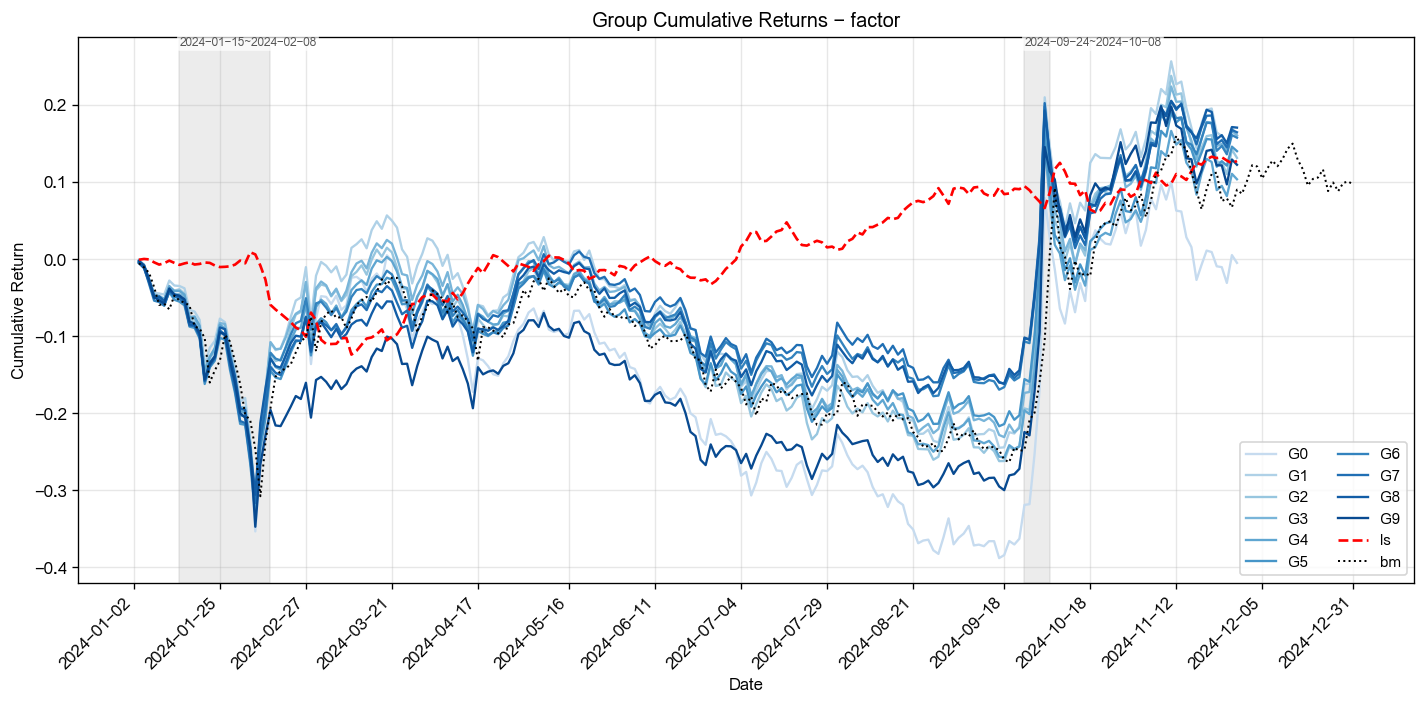
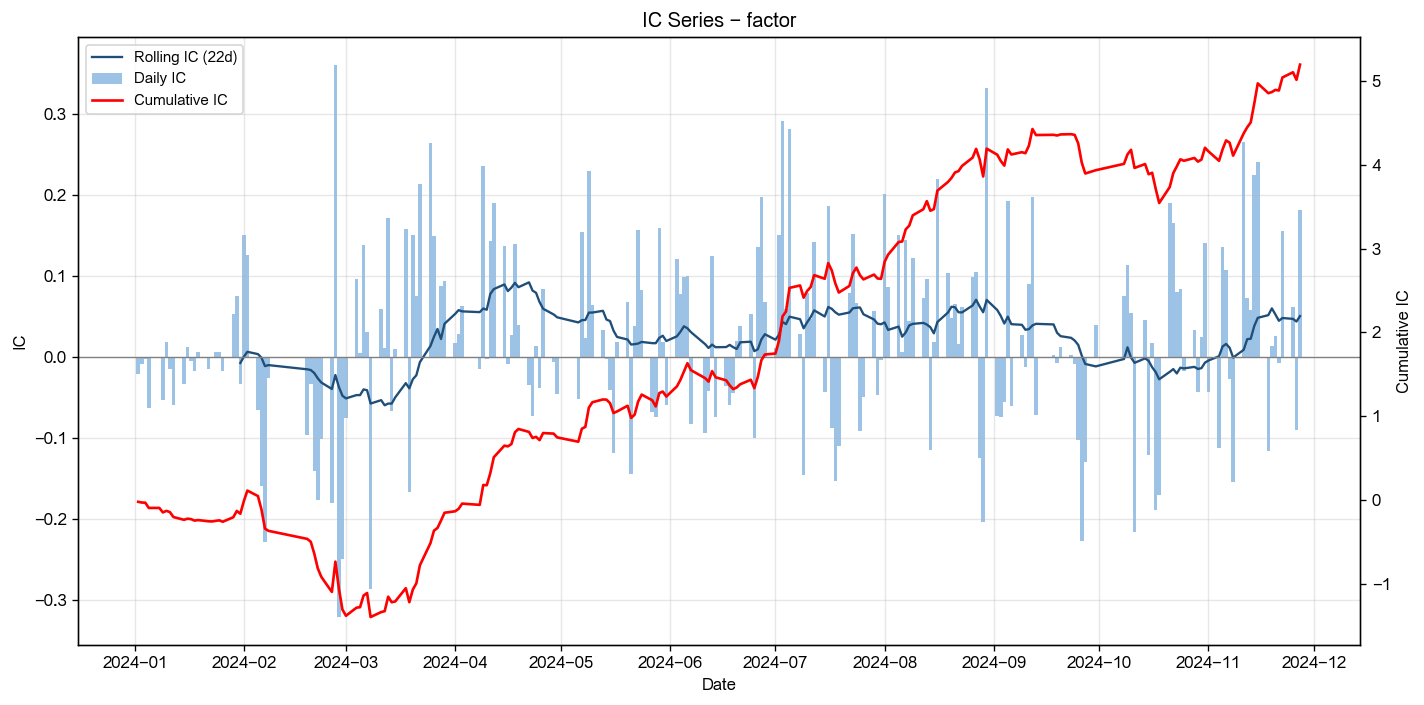
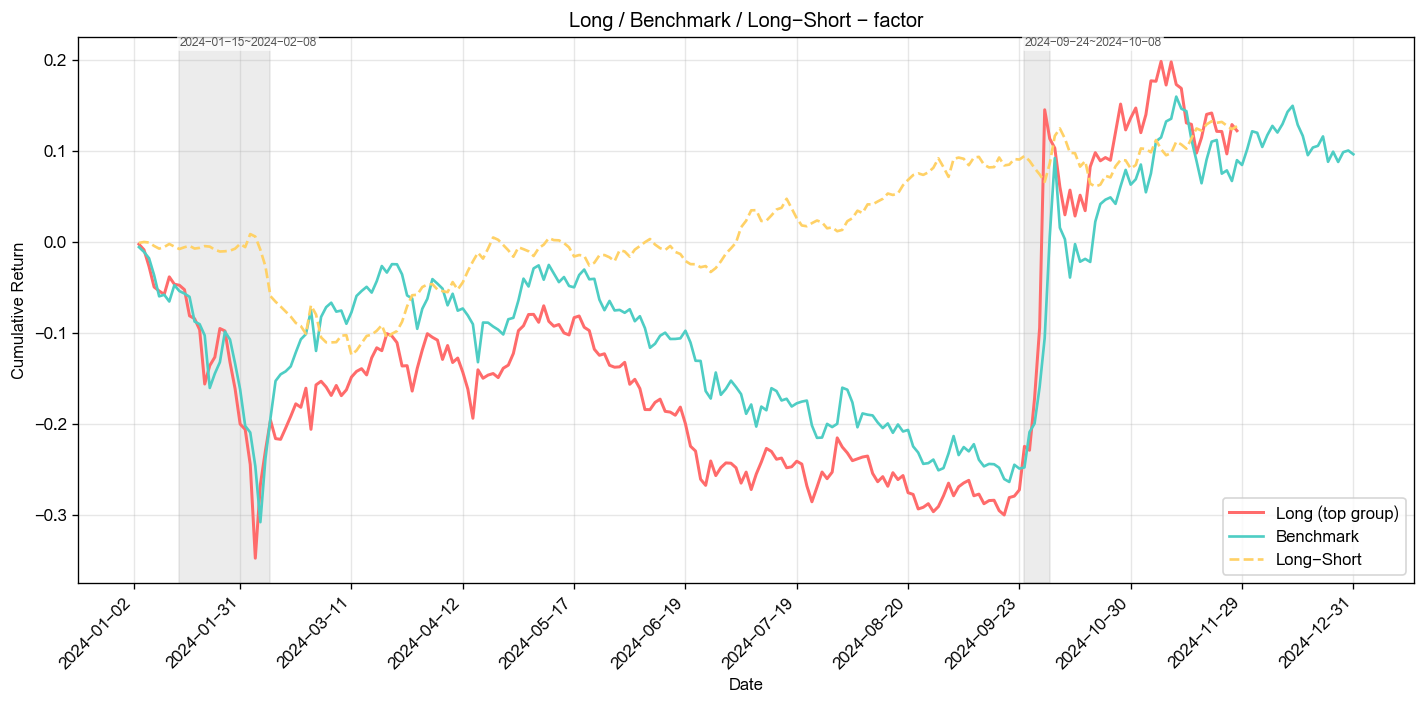
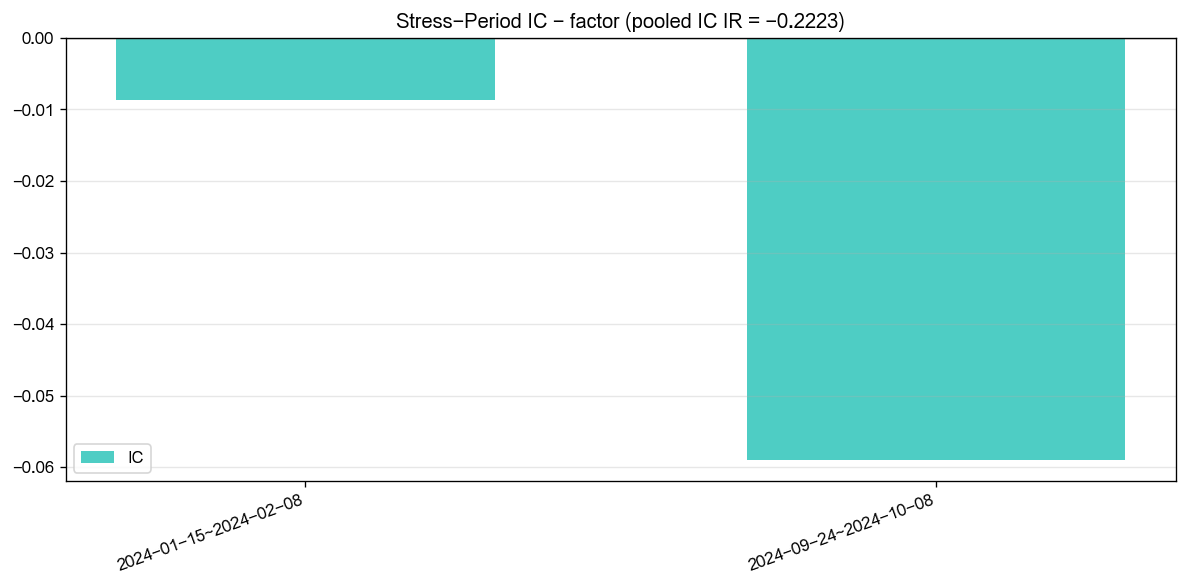
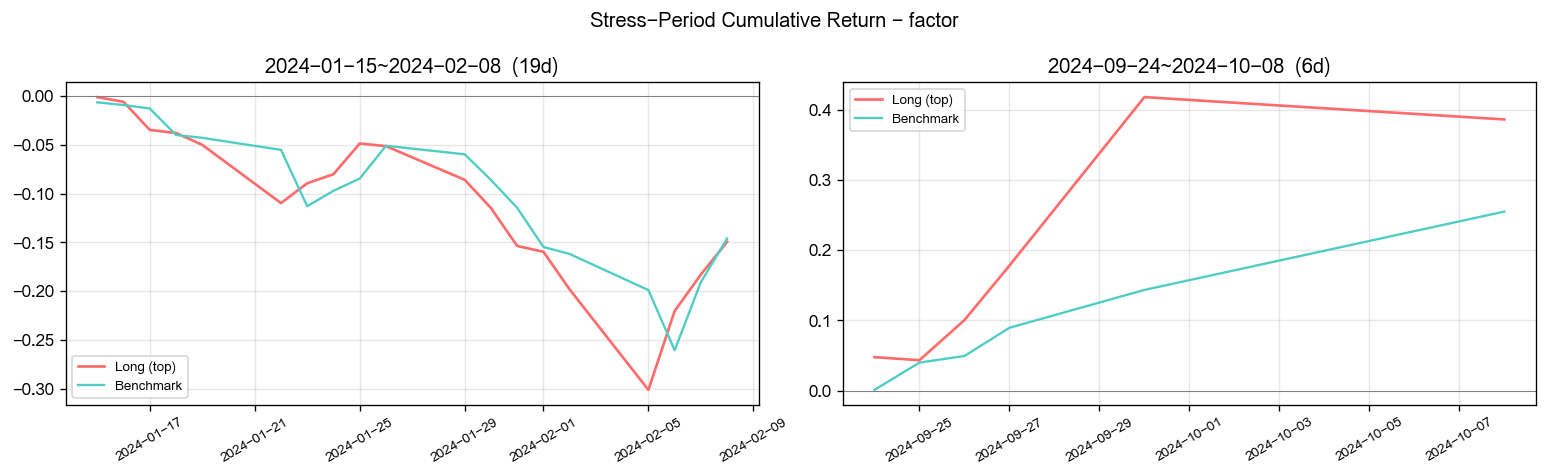

[2026-07-27 17:39:45] [info     ] ========== 因子池回归 ==========
[2026-07-27 17:39:45] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-27 17:39:46] [info     ] 获取收益率数据, 耗时: 0.743 秒
[2026-07-27 17:39:46] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.6025 秒
[2026-07-27 17:39:46] [info     ] 统计 回归结果, 耗时: 0.0114 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9216,0.0444,0.0231,1.0000
2,factor,1.7890,0.0113,0.0063,1.0000
3,amount,1.6677,0.0180,0.0108,0.9000
4,netflow_amount_rate_main,1.5847,0.0100,0.0063,1.0000
5,gross_profit_rate_ttm,1.5141,0.0068,0.0045,1.0000
6,net_profit_rate_ttm,1.4594,0.0040,0.0027,0.8000
7,pb,1.4287,0.0097,0.0068,0.9000
8,netflow_amount_main,1.4183,0.0236,0.0167,1.0000
9,bias_20,1.4059,0.0288,0.0205,0.9000
10,cci_14,1.3768,0.0338,0.0246,1.0000

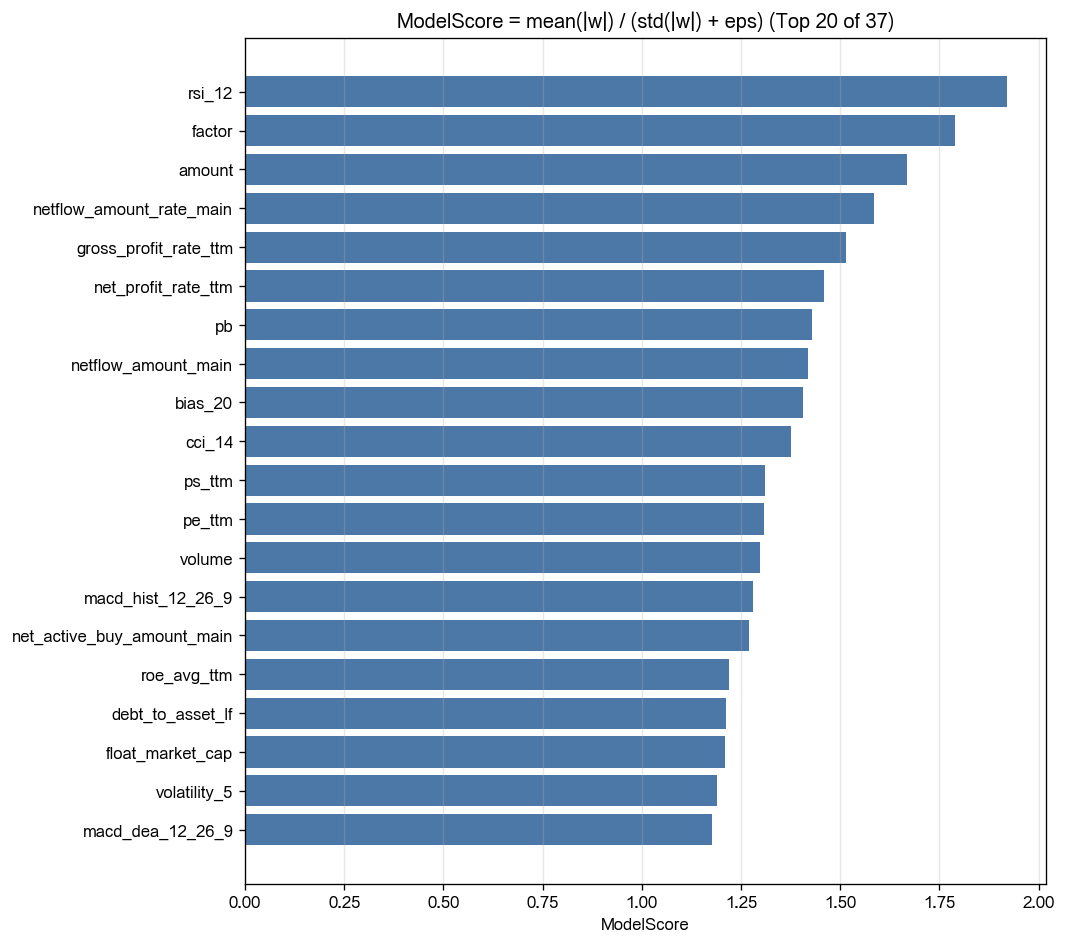
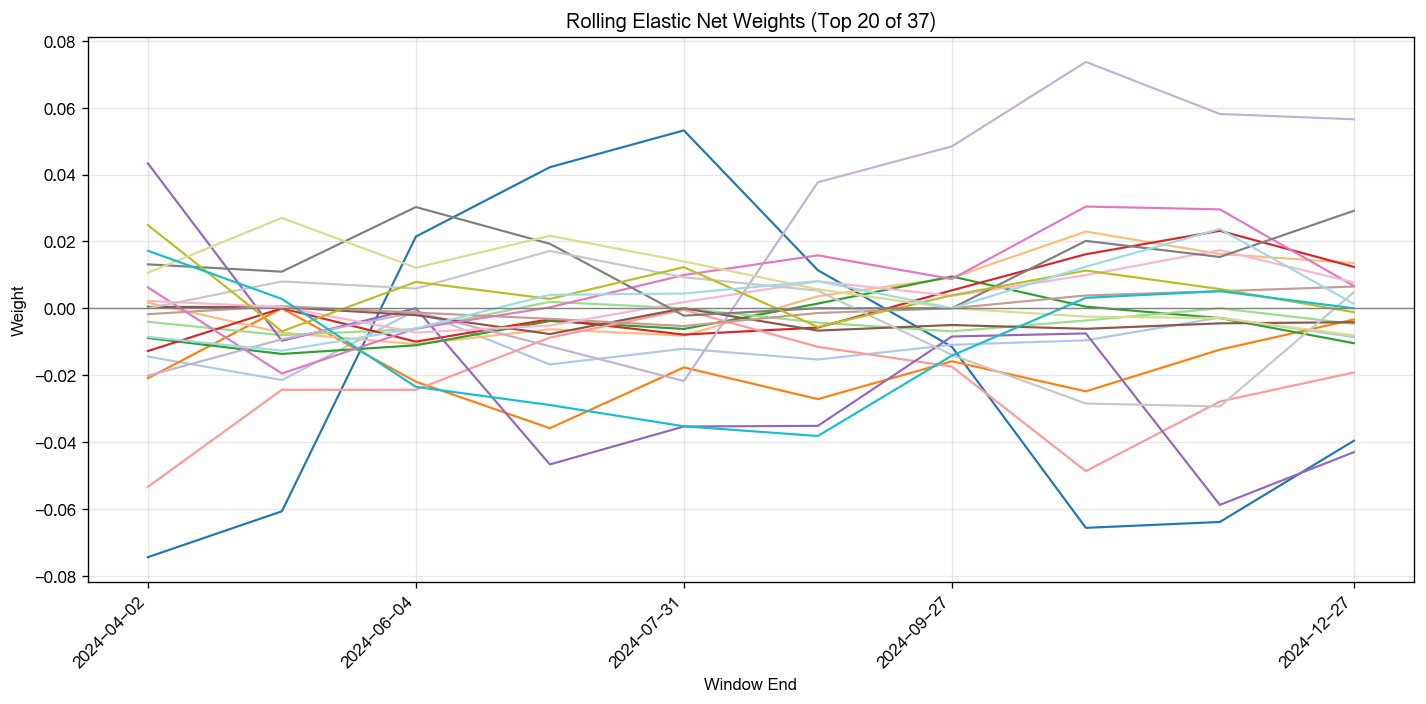
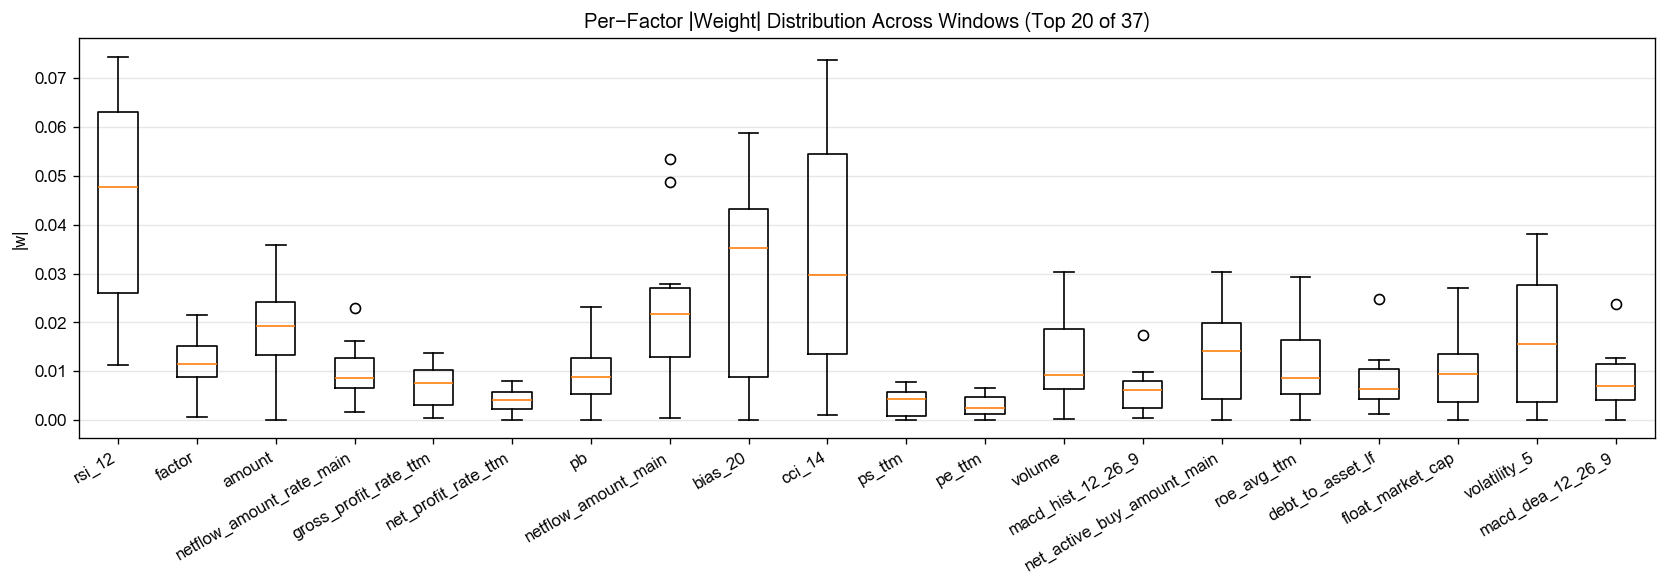
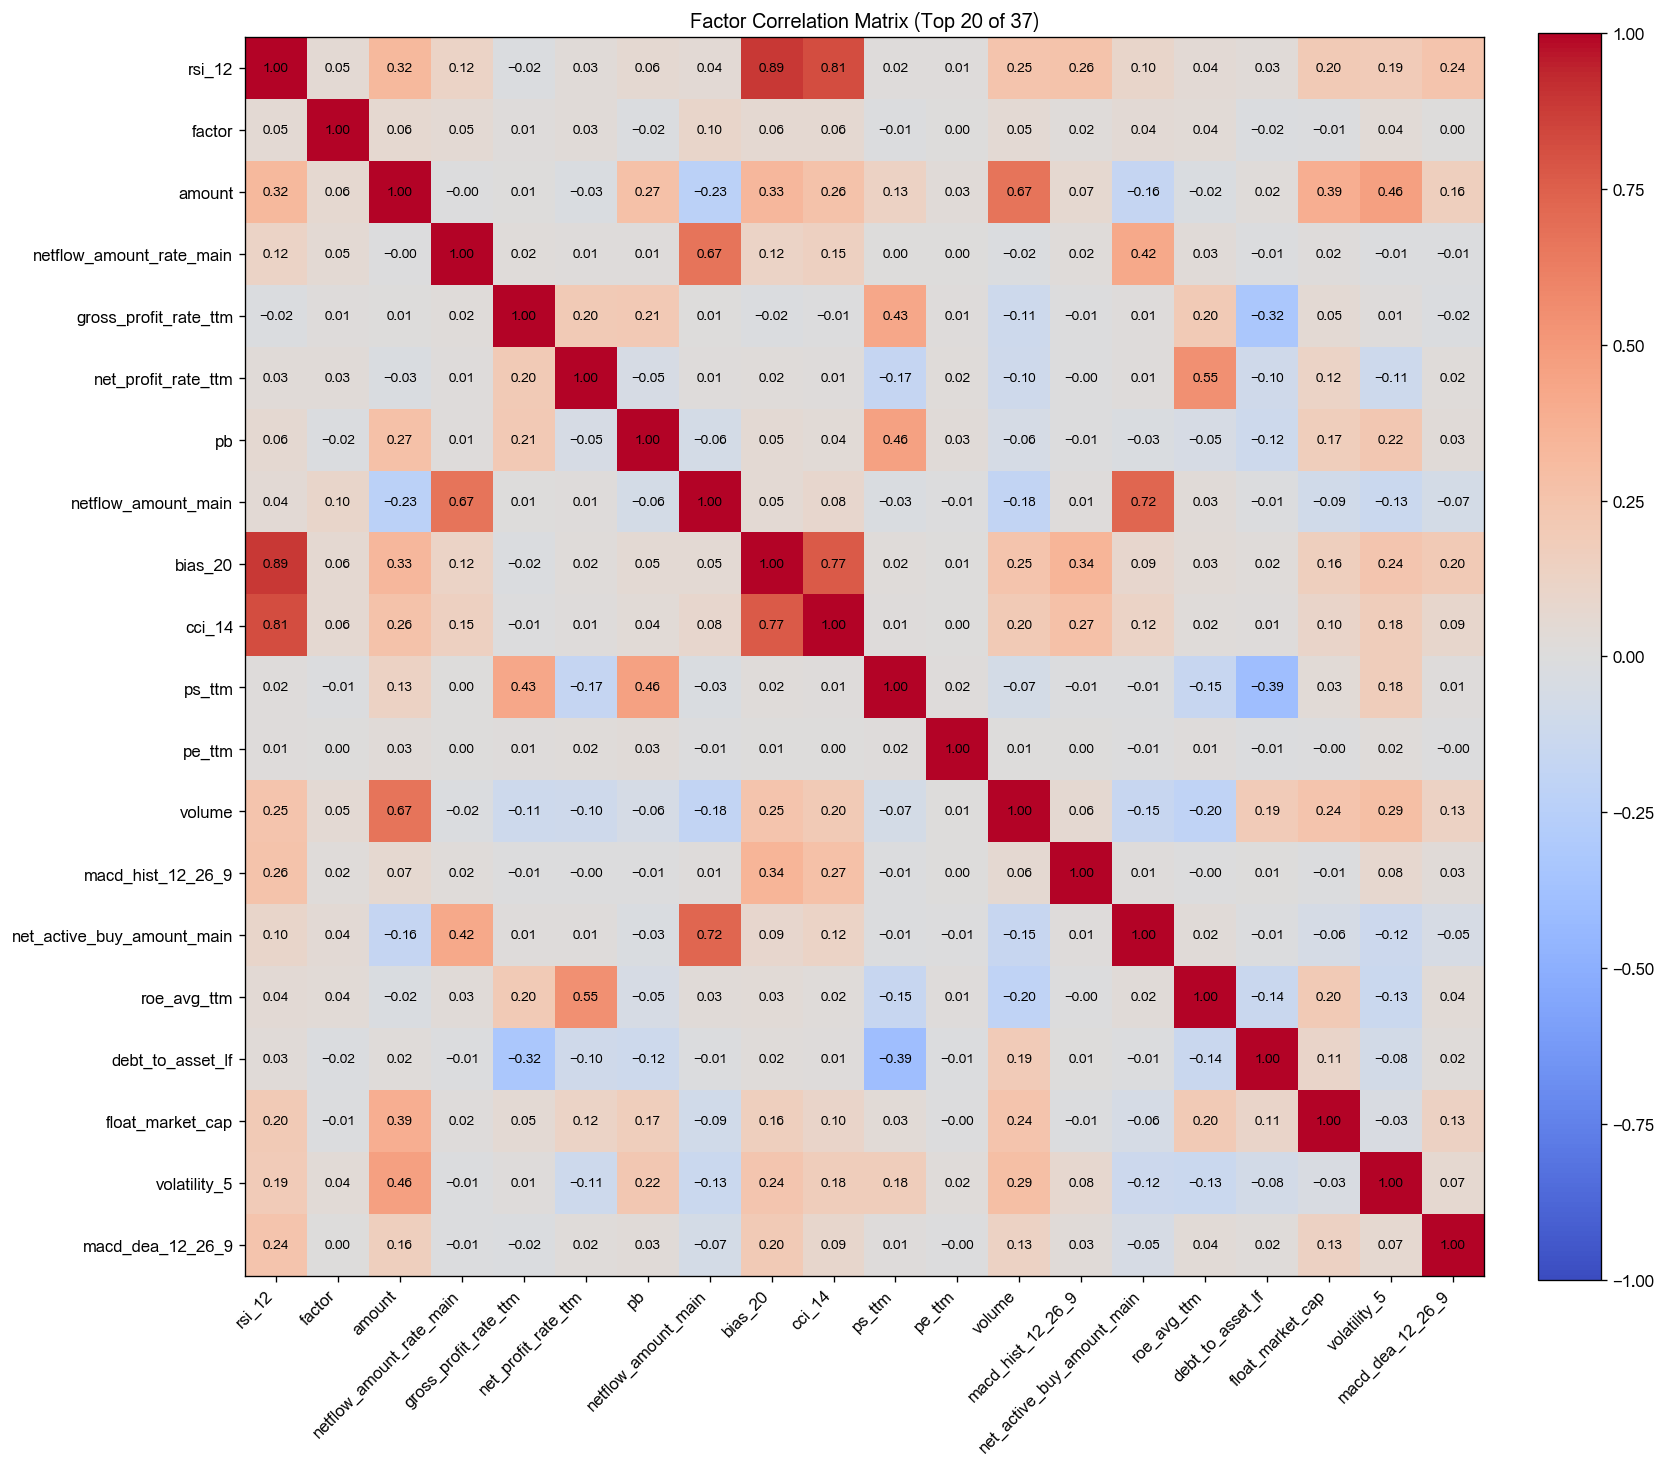

[2026-07-27 17:39:49] [warning  ] 返回的Outputs实例(size=35374441) 大于 64K, 将不会被缓存
[2026-07-27 17:39:49] [info     ] bigalpha_eval.v4 运行完成 [40.475s].
评估完成，评估结果：
{'raw_factor':              date instrument        factor
0      2024-01-02  000006.SZ  4.967142e-08
1      2024-01-02  000012.SZ -1.382643e-08
2      2024-01-02  000016.SZ  6.476885e-08
3      2024-01-02  000019.SZ  1.523030e-07
4      2024-01-02  000025.SZ -2.341534e-08
...           ...        ...           ...
241995 2024-07-19  000801.SZ  5.104087e-08
241996 2024-07-19  000810.SZ -8.861736e-08
241997 2024-07-19  000811.SZ -6.526202e-08
241998 2024-07-19  000813.SZ -1.922111e-07
241999 2024-07-19  000821.SZ  6.756132e-08

[242000 rows x 3 columns], 'process_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.489022
1      2024-01-02  000012.SZ -0.282137
2      2024-01-02  000016.SZ  0.762272
3      2024-01-02  000019.SZ  1.392297
4      2024-01-02  000025.SZ -0.608367
...           ...        ...      

In [1]:
def main(datasources, start_date, end_date):
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]

    # 往前多取 30 天，保证时序 Rolling 20 天窗口和 LAG(1) 跨月连贯
    LOOKBACK_DAYS = 30
    query_start_date = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)).strftime("%Y-%m-%d %H:%M:%S")

    # 一次性将分钟数据压成日频，绝不在分钟级做大窗口，彻底控制占用
    sql = f"""
    WITH cte_bar1m AS (
        SELECT
            date,
            instrument,
            CAST(date AS DATE) AS trading_day,
            high,
            low,
            close,
            (COALESCE(bid_volume1,0)+COALESCE(bid_volume2,0)+COALESCE(bid_volume3,0)+COALESCE(bid_volume4,0)+COALESCE(bid_volume5,0)) AS total_bid_vol,
            (COALESCE(ask_volume1,0)+COALESCE(ask_volume2,0)+COALESCE(ask_volume3,0)+COALESCE(ask_volume4,0)+COALESCE(ask_volume5,0)) AS total_ask_vol
        FROM {bar1m}
        WHERE close > 0
    ),
    cte_daily AS (
        SELECT
            trading_day,
            instrument,
            MAX(high) AS day_high,
            MIN(low) AS day_low,
            LAST(close ORDER BY date) AS close_price,
            SUM(total_bid_vol + total_ask_vol) AS total_order_vol
        FROM cte_bar1m
        GROUP BY instrument, trading_day
    ),
    cte_rolling AS (
        SELECT
            trading_day,
            instrument,
            total_order_vol,
            day_high,
            day_low,
            close_price,
            LAG(close_price, 1) OVER (PARTITION BY instrument ORDER BY trading_day) AS prev_close,
            AVG(total_order_vol) OVER (
                PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
            ) AS history_avg_vol,
            COUNT(total_order_vol) OVER (
                PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
            ) AS valid_count
        FROM cte_daily
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        CAST(
            CASE 
                WHEN prev_close IS NOT NULL AND prev_close > 0
                     AND (day_high >= ROUND(prev_close * 1.10, 2) OR day_low <= ROUND(prev_close * 0.90, 2))
                     AND valid_count >= 5 
                     AND history_avg_vol > 0
                THEN total_order_vol / history_avg_vol
                ELSE 0.0
            END AS FLOAT
        ) AS factor
    FROM cte_rolling
    WHERE trading_day >= CAST('{start_date}' AS DATE)
      AND trading_day <= CAST('{end_date}' AS DATE)
    """

    # 1. 执行 SQL 获取日频因子
    df = dai.query(sql, filters={'date': [query_start_date, end_date]}, compression=True).df()

    # 2. 对齐基准成分股票池（补齐缺失的股票）
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    
    # 统一日期格式，防止 merge 时类型不匹配
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    df['date'] = pd.to_datetime(df['date'])

    df = pd.merge(stk_pool, df, how='left', on=['date', 'instrument'])
    df['factor'] = df['factor'].fillna(0.0)

    # 3. 注入微小扰动噪声，防止截面方差为 0 导致的风格剔除回归失效
    np.random.seed(42)
    df['factor'] = df['factor'] + np.random.normal(0, 1e-7, size=len(df))

    return df[["date", "instrument", "factor"]]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
    print("评估完成，评估结果：")
    print(result)